# Setup

### Holt-Winters

In [4]:
# Mount the drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
%cd /content/drive/MyDrive/Python - Time Series Forecasting (1)/Time Series Analysis/Exponential Smoothing and Holt Winters

/content/drive/.shortcut-targets-by-id/1HWCCj_ENoh3UWoUVaRwtZnL2gIxvz1jG/Python - Time Series Forecasting/Time Series Analysis/Exponential Smoothing and Holt Winters


In [8]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import month_plot, quarter_plot, plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

In [35]:
# Set the index when we import the data
df = pd.read_csv("weekly_customer_complaints.csv", index_col = "week", parse_dates=True)
df.head()

,complaints,discount_rate,small_commercial_event,medium_commercial_event,big_commercial_event
week,,,,,
2018-01-01,"1,750",37.26%,1,0,0
2018-01-08,"1,701",35.38%,0,0,0
2018-01-15,"1,711",36.22%,1,0,0
2018-01-22,"1,443",38.33%,1,0,0
2018-01-29,"1,397",36.34%,0,0,0


In [36]:
# Change the name of the time series variable t y
df = df.rename(columns = {"complaints": "y"})
df.head()

,y,discount_rate,small_commercial_event,medium_commercial_event,big_commercial_event
week,,,,,
2018-01-01,"1,750",37.26%,1,0,0
2018-01-08,"1,701",35.38%,0,0,0
2018-01-15,"1,711",36.22%,1,0,0
2018-01-22,"1,443",38.33%,1,0,0
2018-01-29,"1,397",36.34%,0,0,0


# Data Visualization

In [37]:
# Data type control (1750 is actually 1,750)
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 261 entries, 2018-01-01 to 2022-12-26
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   y                        261 non-null    object
 1   discount_rate            261 non-null    object
 2   small_commercial_event   261 non-null    int64 
 3   medium_commercial_event  261 non-null    int64 
 4   big_commercial_event     261 non-null    int64 
dtypes: int64(3), object(2)
memory usage: 12.2+ KB


In [38]:
# Transform y to integer, remove comma
df["y"] = df["y"].str.replace(",","").astype(int)
df.head()

,y,discount_rate,small_commercial_event,medium_commercial_event,big_commercial_event
week,,,,,
2018-01-01,1750,37.26%,1,0,0
2018-01-08,1701,35.38%,0,0,0
2018-01-15,1711,36.22%,1,0,0
2018-01-22,1443,38.33%,1,0,0
2018-01-29,1397,36.34%,0,0,0


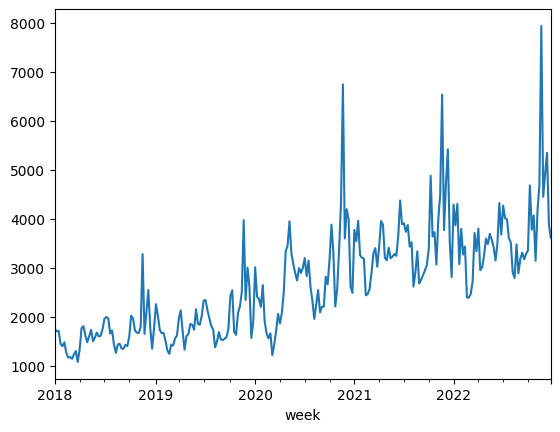

In [39]:
# Daily time series Plot
df["y"].plot()
plt.show()

# Seasonality

In [ ]:
# Plot the month_plot
month_plot(df['y'])
plt.show()

In [ ]:
# Plot the quarter_plot
quarter_plot(df['y'])
plt.show()

In [ ]:
# Seasonal decomposition for df['Adj. Close']
decomposition = seasonal_decompose(df['y'],
                                  model = 'additive',
                                  period = 7)
fig = decomposition.plot()
fig.set_size_inches(18, 10)
plt.show()

# (Partial) Auto-Correlation

In [ ]:
# Plot the ACF of the
fig, ax = plt.subplots(figsize = (12, 6))
plot_acf(df['y'], lags = 100, ax = ax)
plt.show()

In [ ]:
# PACF
fig, ax = plt.subplots(figsize = (12, 6))
plot_pacf(df['y'], lags = 100, ax = ax)
plt.show()

# Model Assessment

In [ ]:
# Function that assesses the model and visualizes the train, test and forecast
def model_assessment(train, test, predictions, chart_title = None):
  # Set the chart size
  plt.figure(figsize = (10, 4))

  # Plot the train, test and forecast
  plt.plot(train, label = "Train")
  plt.plot(test, label = "Test")
  plt.plot(predictions, label = "Forecast")
  plt.title(chart_title)
  plt.legend()
  plt.show()

  # Calculate and print the RMSE, MAE, and MAPE
  rmse = root_mean_squared_error(test, predictions)
  mae = mean_absolute_error(test, predictions)
  mape = mean_absolute_percentage_error(test, predictions)
  print(f"RMSE: {rmse:.0f}")
  print(f"MAE: {mae:.0f}")
  print(f"MAPE: {100 * mape:.1f} %")

# Plot the future

In [ ]:
def plot_future(y, forecast, chart_title = None):
  # Plot the training data and forecast
  plt.figure(figsize = (10, 4))

  # Plot the train, test and forecast
  plt.plot(y, label = "Train")
  plt.plot(forecast, label = "Forecast")

  # Add a title and legend to the plot
  plt.title(chart_title)
  plt.legend()
  plt.show()
